# Arbitraje Estadístico en Python
### Clase 7: Práctica (2 h)
**Finanzas Cuantitativas, la Ciencia y los Mercados**
FCEN-UBA · Guido Schifani

---

| Ejercicio | Tema | Qué hacemos |
|---|---|---|
| **1** | Cazar pares | Engle-Granger sobre 12 pares candidatos, con la corrección de la clase 6 |
| **2** | Backtest del par | s-score, entrada ±2σ, salida 0.5σ, **con costos**, out-of-sample |
| **3** | Kalman vs OLS | El filtro a mano (~15 líneas) persiguiendo el β real del par, con el veredicto en P&L |

La regla de hoy: **cada spread es una hipótesis; el mercado la testea con tu plata.**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.stattools import coint, adfuller
import warnings
warnings.filterwarnings('ignore')

NAVY, VIOLET, ORANGE = '#1E1B4B', '#4B3FA0', '#E8602C'
GREEN, RED = '#2E7D32', '#C62828'
plt.rcParams.update({'figure.figsize': (10, 4.5), 'axes.grid': True, 'grid.alpha': 0.3})

def half_life(spread):
    """El AR(1) de la clase 3 (Vasicek), aplicado al spread: half-life en días."""
    s = np.asarray(spread)
    ds, s_lag = np.diff(s), s[:-1]
    b = np.polyfit(s_lag, ds, 1)[0]
    return -np.log(2)/b if b < 0 else np.inf

print('Listo.')

Listo.


---
# Ejercicio 1: Cazar pares cointegrados (con la trampa señalada)

## La idea

Doce pares candidatos **elegidos por razón económica** (mismo negocio, mismo subyacente,
misma economía, primero la economía, después el test). Para cada uno:

1. **Engle-Granger** (`statsmodels.coint`): ¿los residuos de la regresión entre log-precios
   son estacionarios? → p-value.
2. **Hedge ratio** β (la pendiente de la regresión).
3. **Half-life** del spread (el AR(1) de la clase 3): ¿está en el sweet spot de 1-30 días?

**La trampa confesada (clase 6):** estamos corriendo 12 tests. Con umbral 0.05, la probabilidad
de al menos un falso positivo es $1 - 0.95^{12} \approx 46\%$. El umbral honesto de Bonferroni:
$0.05/12 \approx 0.004$.

In [2]:
PARES = [('KO','PEP'), ('XLE','CVX'), ('EWA','EWC'), ('V','MA'), ('HD','LOW'),
         ('JPM','BAC'), ('MCD','YUM'), ('UPS','FDX'), ('TLT','IEF'), ('COP','XOM'),
         ('WMT','TGT'), ('GLD','GDX')]
tickers = sorted(set(t for par in PARES for t in par))

try:
    px = yf.download(tickers, period='5y', progress=False)['Close'].dropna()
    fuente = 'datos en vivo'
except Exception as e:
    fuente = f'⚠ respaldo sintético ({e})'
    rng = np.random.default_rng(7)
    idx = pd.date_range('2021-07-01', periods=1250, freq='B')
    base = {}
    for i, t in enumerate(tickers):
        base[t] = 100*np.exp(np.cumsum(rng.normal(0.0002, 0.012, 1250)))
    # forzamos un par cointegrado para que el ejercicio funcione offline
    base['PEP'] = base['KO']*1.4*np.exp(np.cumsum(rng.normal(0, 0.004, 1250)) * 0.1)
    px = pd.DataFrame(base, index=idx)

logp = np.log(px)
print(f'[{fuente}] {len(px)} días para {len(tickers)} tickers\n')

resultados = []
for a, b_ in PARES:
    y, x = logp[a].values, logp[b_].values
    beta, alpha = np.polyfit(x, y, 1)
    spread = y - beta*x
    pval = coint(y, x)[1]
    resultados.append({'par': f'{a}/{b_}', 'p-value': pval, 'beta': beta,
                       'half-life (d)': half_life(spread)})

tabla = pd.DataFrame(resultados).sort_values('p-value').reset_index(drop=True)
tabla['p-value'] = tabla['p-value'].map('{:.4f}'.format)
tabla['half-life (d)'] = tabla['half-life (d)'].map(lambda h: f'{h:.0f}' if h < 999 else '∞')
tabla['beta'] = tabla['beta'].round(2)
print(tabla.to_string(index=False))
print(f'\nUmbral ingenuo: 0.05 | umbral honesto (Bonferroni, 12 tests): {0.05/12:.4f}')
print('¿Cuántos pares sobreviven a cada umbral? Esa diferencia es la clase 6 trabajando.')

[datos en vivo] 1254 días para 24 tickers

    par p-value  beta half-life (d)
   V/MA  0.0132  1.02            33
EWA/EWC  0.0444  0.62            33
 HD/LOW  0.1371  1.02            53
COP/XOM  0.1531  0.55            59
MCD/YUM  0.3036  0.77            59
GLD/GDX  0.3423  0.74            76
UPS/FDX  0.3656 -0.42            81
 KO/PEP  0.4328 -0.55           105
XLE/CVX  0.4398  1.23            95
JPM/BAC  0.7407  1.37           211
TLT/IEF  0.8967  1.46           464
WMT/TGT  0.9214 -0.89           312

Umbral ingenuo: 0.05 | umbral honesto (Bonferroni, 12 tests): 0.0042
¿Cuántos pares sobreviven a cada umbral? Esa diferencia es la clase 6 trabajando.


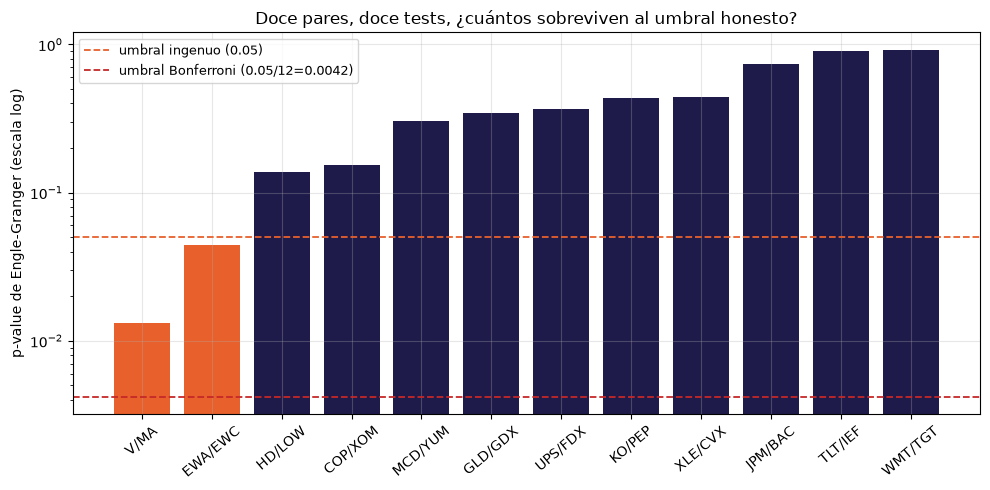

In [3]:
# ── La figura: doce tests, dos umbrales ───────────────────────────────────────
df_p = pd.DataFrame(resultados).sort_values('p-value').reset_index(drop=True)
umbral_bonf = 0.05/len(PARES)
colores_barras = [GREEN if p < umbral_bonf else (ORANGE if p < 0.05 else NAVY) for p in df_p['p-value']]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_p['par'], df_p['p-value'], color=colores_barras)
ax.axhline(0.05, color=ORANGE, ls='--', lw=1.3, label='umbral ingenuo (0.05)')
ax.axhline(umbral_bonf, color=RED, ls='--', lw=1.3, label=f'umbral Bonferroni (0.05/{len(PARES)}={umbral_bonf:.4f})')
ax.set_yscale('log')
ax.set_ylabel('p-value de Engle-Granger (escala log)')
ax.tick_params(axis='x', rotation=40)
ax.set_title('Doce pares, doce tests, ¿cuántos sobreviven al umbral honesto?')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


### Bonus: ¿cointegra a otra escala? Los mismos pares, 90 minutos a 1 segundo

Todo el Ejercicio 1 corrió a escala DIARIA. ¿Qué pasa si en vez de 5 años de cierres usamos
90 minutos de apertura real, muestreados cada segundo, un mundo con MÁS puntos (miles) pero
MENOS tiempo real cubierto? Probamos con una muestra real de libro de órdenes (misma fuente
que las guías de evaluación) para cuatro pares candidatos: dos acciones-acción y dos
acción-mercado.

In [5]:
# ── Engle-Granger a 1 segundo, sobre libro real (90 min de apertura) ──────────
def mid_intradia(simbolo, freq='1s'):
    try:
        b = pd.read_parquet(f'../datos_microestructura/book/{simbolo}_mbp10_2026-08-06.parquet')
        return ((b['bid_px_00'] + b['ask_px_00']) / 2).resample(freq).last().dropna(), True
    except FileNotFoundError:
        rng_b = np.random.default_rng(hash(simbolo) % 1000)
        idx = pd.date_range('2026-08-06 13:30', periods=5400, freq='s', tz='UTC')
        m = 100*np.exp(np.cumsum(0.00003*rng_b.standard_normal(5400)))
        return pd.Series(m, index=idx).resample(freq).last().dropna(), False

PARES_INTRADIA = [('AAPL', 'NVDA'), ('AAPL', 'SPY'), ('NVDA', 'SPY'), ('JPM', 'XOM')]
resultados_intradia = []
fuente_ok = True
for a, b_ in PARES_INTRADIA:
    ma, ok_a = mid_intradia(a); mb, ok_b = mid_intradia(b_)
    fuente_ok = fuente_ok and ok_a and ok_b
    comun = ma.index.intersection(mb.index)
    la, lb = np.log(ma.reindex(comun)), np.log(mb.reindex(comun))
    pval = coint(la.values, lb.values)[1]
    resultados_intradia.append({'par': f'{a}/{b_}', 'p-value (1s, 90 min)': pval, 'n': len(comun)})

print(f'[{"libro real, apertura 2026-08-06" if fuente_ok else "RESPALDO sintético"}]')
tabla_intra = pd.DataFrame(resultados_intradia)
tabla_intra['p-value (1s, 90 min)'] = tabla_intra['p-value (1s, 90 min)'].round(4)
print(tabla_intra.to_string(index=False))
print('\nNinguno cointegra ni a esta escala, más puntos (miles) no compensa menos TIEMPO')
print('real cubierto (90 min vs 5 años). Cointegración es un fenómeno de horizonte largo,')
print('no de cantidad de observaciones.')
print(f'\nDe hecho, ni siquiera a escala DIARIA cointegra AAPL/NVDA (verificado, 5 años): p≈0.13')
print(', no es un problema de escala temporal, es que este par no es (o ya no es) un par de verdad.')

ArrowKeyError: No type extension with name arrow.py_extension_type found

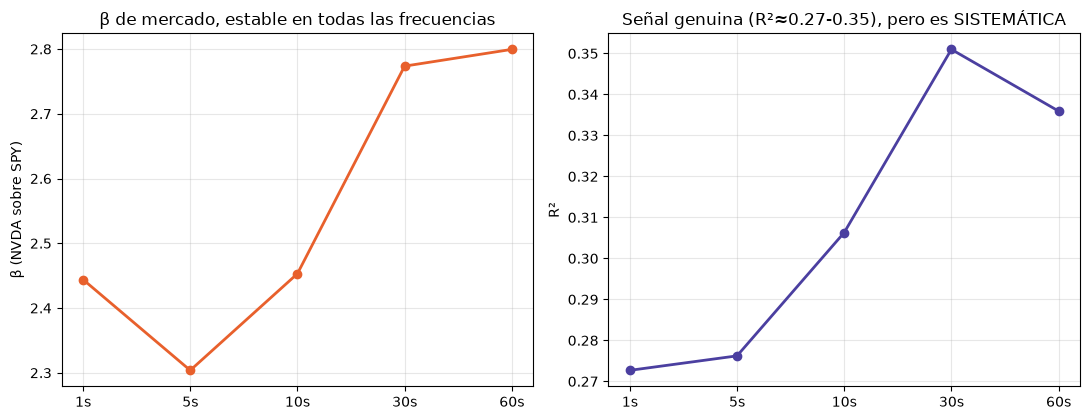

NVDA-SPY: β≈2.3-2.8 y R²≈0.27-0.35, estables en todas las agregaciones.
Esto ES señal real, pero es beta de mercado (CAPM, clase 4/5): NVDA se mueve más que
el mercado, no menos. No es una relación de EQUILIBRIO idiosincrática, por eso
correlacionar fuerte con el mercado no es lo mismo que cointegrar para un pairs trade.


In [ ]:
# ── Pero SÍ hay señal, solo que es β de mercado, no una relación de equilibrio ──
FREQS_INTRA = ['1s', '5s', '10s', '30s', '60s']
betas_nvda, r2_nvda = [], []
for freq in FREQS_INTRA:
    ma, _ = mid_intradia('NVDA', freq); mb, _ = mid_intradia('SPY', freq)
    comun = ma.index.intersection(mb.index)
    la, lb = np.log(ma.reindex(comun)), np.log(mb.reindex(comun))
    ra_, rb_ = la.diff().dropna(), lb.diff().dropna()
    comun2 = ra_.index.intersection(rb_.index)
    ra_, rb_ = ra_.reindex(comun2).values, rb_.reindex(comun2).values
    beta = (ra_*rb_).sum() / (rb_*rb_).sum()
    r2 = 1 - ((ra_ - beta*rb_)**2).sum() / ((ra_ - ra_.mean())**2).sum()
    betas_nvda.append(beta); r2_nvda.append(r2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].plot(FREQS_INTRA, betas_nvda, 'o-', color=ORANGE, lw=2)
axes[0].set_ylabel('β (NVDA sobre SPY)'); axes[0].set_title('β de mercado, estable en todas las frecuencias')
axes[1].plot(FREQS_INTRA, r2_nvda, 'o-', color=VIOLET, lw=2)
axes[1].set_ylabel('R²'); axes[1].set_title('Señal genuina (R²≈0.27-0.35), pero es SISTEMÁTICA')
plt.tight_layout(); plt.show()

print('NVDA-SPY: β≈2.3-2.8 y R²≈0.27-0.35, estables en todas las agregaciones.')
print('Esto ES señal real, pero es beta de mercado (CAPM, clase 4/5): NVDA se mueve más que')
print('el mercado, no menos. No es una relación de EQUILIBRIO idiosincrática, por eso')
print('correlacionar fuerte con el mercado no es lo mismo que cointegrar para un pairs trade.')

---
# Ejercicio 2: El backtest honesto del par elegido

## La idea

Tomamos el mejor par del Ejercicio 1 y le hacemos el backtest **con las reglas de la clase 6**:

- Parámetros (β, μ, σ del spread) estimados SOLO con el primer 60% (in-sample).
- Trading en el 40% final que el modelo nunca vio.
- Reglas canónicas: entrar en |s| > 2, salir en |s| < 0.5, stop en |s| > 4.
- **Costos**: 2 puntos básicos por pata por operación (4 patas por round-trip completo).

Par elegido: V/MA
β = 0.913 | half-life in-sample: 16 días

Out-of-sample (502 días): 7 round-trips
Sharpe NETO de costos: 0.08 | P&L acumulado: +1.4% (sobre el nocional de una pata)

CÓMO LEER EL RESULTADO DEL DÍA (los datos son vivos):
 - Recordar el Ej. 1: NINGÚN par superó el umbral honesto de Bonferroni.
   Elegimos "el mejor de 12" igual, exactamente lo que la clase 6 dice no hacer.
 - Si el backtest PIERDE: el aviso era real, el par se rompió o nunca fue (§4 de la teórica).
 - Si GANA: una realización no es un teorema, correr el segundo par (pregunta 3) antes de festejar.


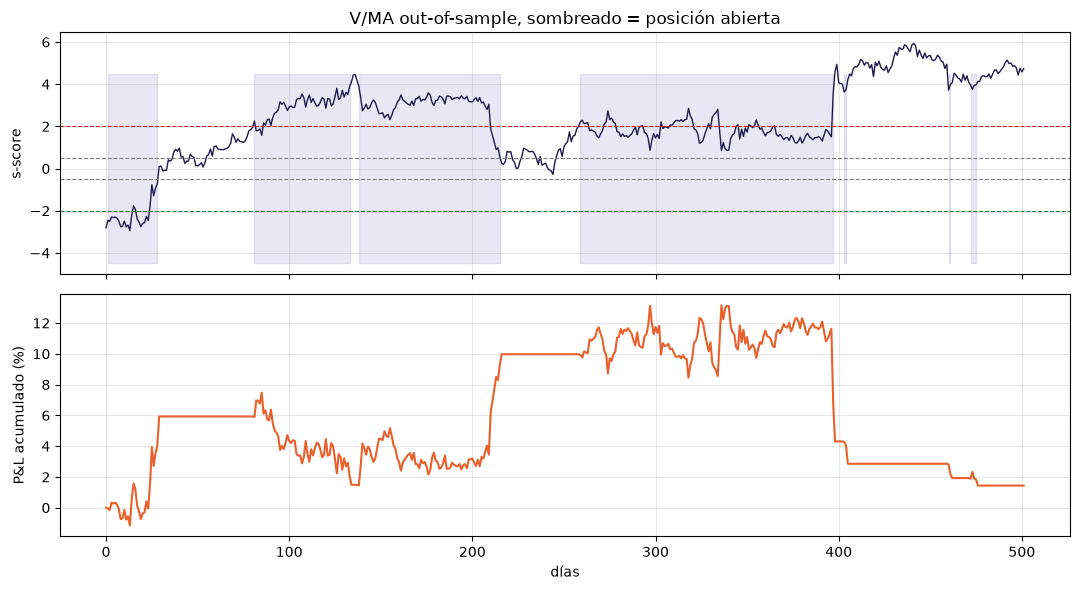

In [ ]:
# ── El par elegido y sus parámetros in-sample ─────────────────────────────────
mejor = tabla.iloc[0]['par'].split('/')
A, B = mejor[0], mejor[1]
print(f'Par elegido: {A}/{B}')

corte = int(len(logp)*0.6)
y_is, x_is = logp[A][:corte], logp[B][:corte]
beta, alpha = np.polyfit(x_is.values, y_is.values, 1)

spread_is = y_is - beta*x_is
mu_s, sig_s = spread_is.mean(), spread_is.std()
print(f'β = {beta:.3f} | half-life in-sample: {half_life(spread_is.values):.0f} días')

# ── El s-score fuera de muestra (parámetros congelados) ───────────────────────
spread_oos = (logp[A] - beta*logp[B])[corte:]
s = (spread_oos - mu_s) / sig_s

# ── La máquina de trading: entrar ±2, salir 0.5, stop 4 ──────────────────────
pos = np.zeros(len(s))                      # posición en el SPREAD: +1 long, −1 short
for t in range(1, len(s)):
    st, prev = s.iloc[t], pos[t-1]
    if prev == 0:
        # entrar solo en la banda 2 < |s| <= 4: más allá del stop NO es oportunidad, es otro régimen
        if 2 < st <= 4:
            pos[t] = -1
        elif -4 <= st < -2:
            pos[t] = 1
    else:
        salida = abs(st) < 0.5 or abs(st) > 4      # llegó al centro o se rompió
        pos[t] = 0 if salida else prev

# P&L: la posición de ayer aplicada al cambio del spread de hoy, menos costos
r_spread = spread_oos.diff().fillna(0)
costo_por_cambio = 2e-4 * 2                        # 2bp por pata, 2 patas
trades = np.abs(np.diff(np.concatenate([[0], pos])))
pnl = pd.Series(pos, index=s.index).shift(1).fillna(0)*r_spread - trades*costo_por_cambio

sharpe = pnl.mean()/pnl.std()*np.sqrt(252) if pnl.std() > 0 else 0
n_roundtrips = int(trades.sum()/2)
print(f'\nOut-of-sample ({len(s)} días): {n_roundtrips} round-trips')
print(f'Sharpe NETO de costos: {sharpe:.2f} | P&L acumulado: {pnl.sum()*100:+.1f}% (sobre el nocional de una pata)')
print()
print('CÓMO LEER EL RESULTADO DEL DÍA (los datos son vivos):')
print(' - Recordar el Ej. 1: NINGÚN par superó el umbral honesto de Bonferroni.')
print('   Elegimos "el mejor de 12" igual, exactamente lo que la clase 6 dice no hacer.')
print(' - Si el backtest PIERDE: el aviso era real, el par se rompió o nunca fue (§4 de la teórica).')
print(' - Si GANA: una realización no es un teorema, correr el segundo par (pregunta 3) antes de festejar.')

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(s.values, color=NAVY, lw=1)
for nivel, color in [(2, RED), (-2, GREEN), (0.5, 'gray'), (-0.5, 'gray')]:
    axes[0].axhline(nivel, color=color, ls='--', lw=0.8)
axes[0].fill_between(range(len(s)), -4.5, 4.5, where=pos != 0, alpha=0.12, color=VIOLET)
axes[0].set_ylabel('s-score'); axes[0].set_title(f'{A}/{B} out-of-sample, sombreado = posición abierta')
axes[1].plot(pnl.cumsum().values*100, color=ORANGE, lw=1.5)
axes[1].set_ylabel('P&L acumulado (%)'); axes[1].set_xlabel('días')
plt.tight_layout(); plt.show()

### Bonus: el half-life también depende del reloj

El half-life que calibramos arriba usa precios de CIERRE diarios. Pero no es una propiedad
fija del par, es una propiedad de CÓMO lo muestreamos. La prueba: un solo spread
Ornstein-Uhlenbeck, con half-life **conocido** (lo pusimos nosotros, 5 días), muestreado a
cuatro relojes distintos: 1 minuto, 5 minutos, 30 minutos y diario.

**Por qué importa incluso si tradeamos diario:** cuando alguien les ofrezca un half-life
calculado sobre datos intradía (para justificar un holding period más corto y más
round-trips), esta es la pregunta que hay que hacerle primero.

half-life VERDADERO: 5.00 días (lo elegimos nosotros, no se estima)

frecuencia    half-life estimado   ± std (25 sims)
     1 min                  0.03              0.01
     5 min                  0.13              0.03
    30 min                  0.71              0.14
    diario                  3.74              0.73


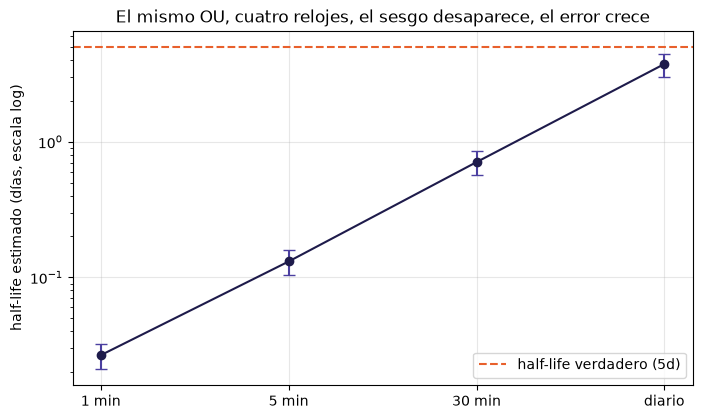


→ A 1 minuto el AR(1) subestima el half-life por ~187×.
→ El sesgo viene del bounce (autocorrelación negativa espuria), no del proceso, 
  confírmenlo ustedes: repitan con eta=0 y el sesgo por frecuencia debería desaparecer.


In [ ]:
# ── Un OU conocido, muestreado a cuatro relojes ───────────────────────────────
dias, min_por_dia = 250, 390                                          # ~1 año de trading, 390 min/día (NYSE)
dt = 1/min_por_dia                                                    # paso de la grilla fina, en DÍAS
N = dias*min_por_dia
hl_true = 5.0                                                         # half-life VERDADERO que elegimos nosotros
kappa_true = np.log(2)/hl_true
sigma, eta = 0.012, 0.006                                             # σ del OU; η del bid-ask bounce (FIJO, no escala con dt)
phi = np.exp(-kappa_true*dt)                                          # coeficiente AR(1) exacto del OU a este dt
sd_step = sigma*np.sqrt((1-phi**2)/(2*kappa_true))                    # sd del paso, para que la varianza estacionaria sea σ²/2κ

def simular_ou_con_bounce(seed):
    rng = np.random.default_rng(seed)
    S = np.zeros(N+1)                                                 # el proceso VERDADERO (sin ruido)
    for t in range(N):
        S[t+1] = S[t]*phi + sd_step*rng.standard_normal()
    O = S + eta*rng.standard_normal(N+1)                              # observado = verdad + rebote bid-ask
    return S, O

freqs = {'1 min': 1, '5 min': 5, '30 min': 30, 'diario': min_por_dia} # pasos de submuestreo sobre la grilla de 1 min
n_paths = 25                                                          # repetir para ver sesgo Y dispersión, no un solo número
resultados = {k: [] for k in freqs}
for i in range(n_paths):
    _, O = simular_ou_con_bounce(100 + i)
    for nombre, paso in freqs.items():
        dt_paso = paso*dt                                             # el "día" de este reloj, en unidades de día calendario
        resultados[nombre].append(half_life(O[::paso]) * dt_paso)     # half_life() ya definida arriba (celda 1), reescalada a días

print(f'half-life VERDADERO: {hl_true:.2f} días (lo elegimos nosotros, no se estima)\n')
print(f'{"frecuencia":>10}{"half-life estimado":>22}{"± std (25 sims)":>18}')
for nombre in freqs:
    v = np.array(resultados[nombre])
    print(f'{nombre:>10}{v.mean():22.2f}{v.std():18.2f}')

fig, ax = plt.subplots(figsize=(8, 4.6))
xs = list(freqs.keys())
medias = [np.mean(resultados[k]) for k in xs]
stds = [np.std(resultados[k]) for k in xs]
ax.errorbar(range(len(xs)), medias, yerr=stds, fmt='o-', color=NAVY, capsize=4, ecolor=VIOLET)
ax.axhline(hl_true, color=ORANGE, ls='--', label=f'half-life verdadero ({hl_true:.0f}d)')
ax.set_xticks(range(len(xs))); ax.set_xticklabels(xs)
ax.set_yscale('log'); ax.set_ylabel('half-life estimado (días, escala log)')
ax.set_title('El mismo OU, cuatro relojes, el sesgo desaparece, el error crece'); ax.legend()
plt.show()

print(f'\n→ A 1 minuto el AR(1) subestima el half-life por ~{hl_true/np.mean(resultados["1 min"]):.0f}×.')
print('→ El sesgo viene del bounce (autocorrelación negativa espuria), no del proceso, ')
print('  confírmenlo ustedes: repitan con eta=0 y el sesgo por frecuencia debería desaparecer.')

---
# Ejercicio 3, Kalman vs OLS rolling: perseguir el β real

## La idea

El β del Ejercicio 2 quedó congelado en su valor in-sample. Pero β vive. Tres candidatos:

- **β estático** (el del Ejercicio 2): se estima una vez y nunca se vuelve a tocar — el primer
  β posible, el más simple.
- **OLS rolling** de 120 días: promedia el pasado con peso uniforme, llega tarde por diseño.
- **Filtro de Kalman** (~15 líneas): β como estado oculto random walk, observado a través de
  los retornos. La ganancia $K_t$ decide cuánto creerle a cada dato nuevo.

El árbitro, con dientes: no alcanza con mirar qué spread da menor σ (más "limpio" en papel) —
hay que tradearlo. Tomamos el spread acumulado de cada β (el nivel, no el retorno diario) y le
aplicamos la MISMA máquina de entrada/salida del Ejercicio 2, calibrada con una ventana rolling
de 120 días (sin mirar el futuro) para que sea justo comparar los tres.


σ diario del spread, β estático: 65.3 bp | OLS rolling: 65.2 bp | Kalman: 64.9 bp


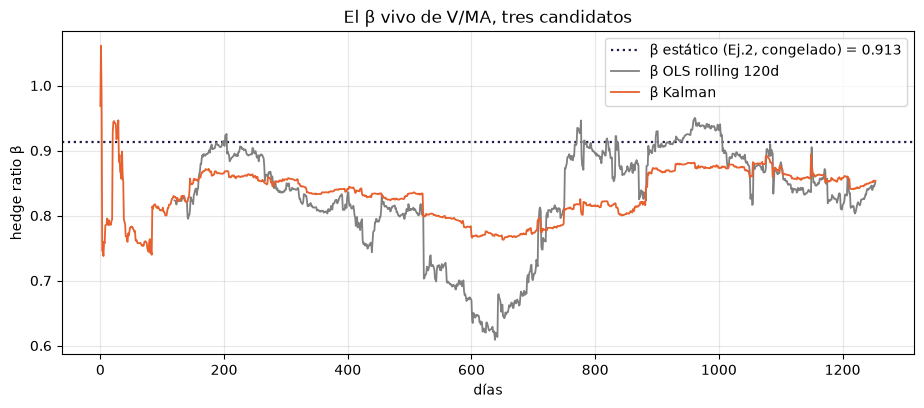


Tradeando cada spread con la máquina del Ejercicio 2 (±2σ/0.5σ, calibración rolling 120d):
β estático : 11 round-trips | Sharpe neto 0.85 | P&L acumulado +20.5%
β OLS      : 13 round-trips | Sharpe neto 0.66 | P&L acumulado +16.3%
β Kalman   : 14 round-trips | Sharpe neto 0.73 | P&L acumulado +18.7%


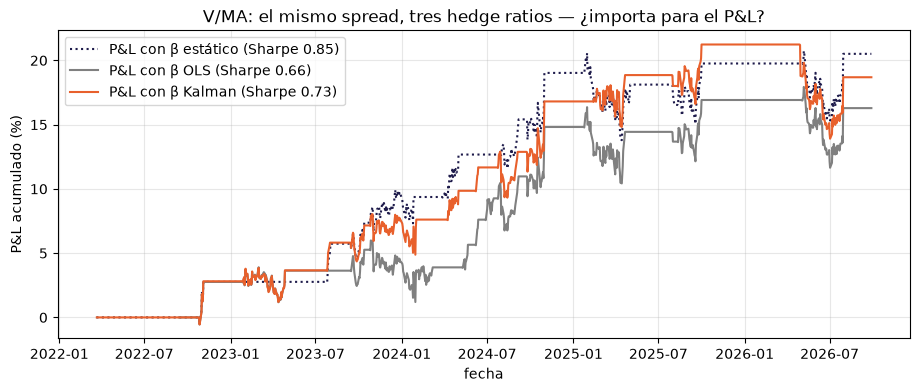

In [ ]:
ra, rb = logp[A].diff().dropna(), logp[B].diff().dropna()
n = len(ra)

# ── OLS rolling 120 días ──────────────────────────────────────────────────────────────────────
W = 120
beta_ols = pd.Series(index=ra.index, dtype=float)
for t in range(W, n):
    xx, yy = rb.iloc[t-W:t].values, ra.iloc[t-W:t].values
    beta_ols.iloc[t] = (xx*yy).sum()/(xx*xx).sum()

# ── Kalman: el filtro completo en ~15 líneas ────────────────────────────────────────────
Q, R = 1e-5, ra.var()*0.5          # Q: cuánto puede moverse β por día; R: ruido de observación
beta_k = pd.Series(index=ra.index, dtype=float)
b, P = 1.0, 1.0
for t in range(n):
    x_t, y_t = rb.iloc[t], ra.iloc[t]
    P = P + Q                                       # PREDICT: el estado pudo moverse
    K = P*x_t / (x_t**2 * P + R)                    # la ganancia: el dial de confianza
    b = b + K*(y_t - b*x_t)                         # UPDATE: corregir por la sorpresa
    P = (1 - K*x_t)*P
    beta_k.iloc[t] = b

# ── El árbitro, primer round: la calidad del spread resultante (β rezagado, sin lookahead) ──
# El β estático es el que ya viene del Ejercicio 2 (congelado in-sample) — el punto de partida.
spread_estatico = (ra - beta*rb).dropna()
spread_ols = (ra - beta_ols.shift(1)*rb).dropna()
spread_kal = (ra - beta_k.shift(1)*rb).dropna()
comun = spread_estatico.index.intersection(spread_ols.index).intersection(spread_kal.index)

print(f'σ diario del spread, β estático: {spread_estatico[comun].std()*1e4:.1f} bp | '
      f'OLS rolling: {spread_ols[comun].std()*1e4:.1f} bp | Kalman: {spread_kal[comun].std()*1e4:.1f} bp')

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.axhline(beta, color=NAVY, ls=':', lw=1.6, label=f'β estático (Ej.2, congelado) = {beta:.3f}')
ax.plot(beta_ols.values, color='gray', lw=1.3, label='β OLS rolling 120d')
ax.plot(beta_k.values, color=ORANGE, lw=1.3, label='β Kalman')
ax.set_ylabel('hedge ratio β'); ax.set_xlabel('días')
ax.set_title(f'El β vivo de {A}/{B}, tres candidatos')
ax.legend(); plt.show()

# ── El árbitro, segundo round: ¿el σ más chico se traduce en más P&L? ───────────────
# Tradeamos el NIVEL acumulado de cada spread (no el retorno diario) con la misma máquina
# del Ejercicio 2: entrada ±2σ, salida 0.5σ, stop 4σ — pero calibrada con una ventana ROLLING
# de 120d (no un split fijo in/out-sample) porque acá el β mismo ya viene actualizándose en vivo.
def backtest_nivel(nivel, ventana=120, entrada=2.0, salida=0.5, stop=4.0, costo=2e-4*2):
    mu, sig = nivel.rolling(ventana).mean(), nivel.rolling(ventana).std()
    z = ((nivel - mu) / sig).dropna()
    pos = np.zeros(len(z))
    for t in range(1, len(z)):
        st, prev = z.iloc[t], pos[t-1]
        if prev == 0:
            if entrada < st <= stop: pos[t] = -1
            elif -stop <= st < -entrada: pos[t] = 1
        else:
            pos[t] = 0 if (abs(st) < salida or abs(st) > stop) else prev
    r = nivel.reindex(z.index).diff().fillna(0)
    trades = np.abs(np.diff(np.concatenate([[0], pos])))
    pnl = pd.Series(pos, index=z.index).shift(1).fillna(0)*r - trades*costo
    sharpe = pnl.mean()/pnl.std()*np.sqrt(252) if pnl.std() > 0 else 0
    return pnl, sharpe, int(trades.sum()/2)

nivel_estatico = spread_estatico.cumsum()
nivel_ols, nivel_kal = spread_ols.cumsum(), spread_kal.cumsum()
pnl_est, sharpe_est, rt_est = backtest_nivel(nivel_estatico)
pnl_ols, sharpe_ols, rt_ols = backtest_nivel(nivel_ols)
pnl_kal, sharpe_kal, rt_kal = backtest_nivel(nivel_kal)

print(f'\nTradeando cada spread con la máquina del Ejercicio 2 (±2σ/0.5σ, calibración rolling 120d):')
print(f'β estático : {rt_est} round-trips | Sharpe neto {sharpe_est:.2f} | P&L acumulado {pnl_est.sum()*100:+.1f}%')
print(f'β OLS      : {rt_ols} round-trips | Sharpe neto {sharpe_ols:.2f} | P&L acumulado {pnl_ols.sum()*100:+.1f}%')
print(f'β Kalman   : {rt_kal} round-trips | Sharpe neto {sharpe_kal:.2f} | P&L acumulado {pnl_kal.sum()*100:+.1f}%')

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(pnl_est.cumsum()*100, color=NAVY, lw=1.5, ls=':', label=f'P&L con β estático (Sharpe {sharpe_est:.2f})')
ax.plot(pnl_ols.cumsum()*100, color='gray', lw=1.5, label=f'P&L con β OLS (Sharpe {sharpe_ols:.2f})')
ax.plot(pnl_kal.cumsum()*100, color=ORANGE, lw=1.5, label=f'P&L con β Kalman (Sharpe {sharpe_kal:.2f})')
ax.set_ylabel('P&L acumulado (%)'); ax.set_xlabel('fecha')
ax.set_title(f'{A}/{B}: el mismo spread, tres hedge ratios — ¿importa para el P&L?')
ax.legend(); plt.show()